# Example: Estimating Single Index Models from Historical Data
In this example, we estimate the single index model (SIM) of the lecture from the 2014 to 2024 training data. We build the growth-rate matrix, take the SPY exchange-traded fund as the market index $M$, fit the model for one firm by least squares three different ways (and check that they agree), quantify the uncertainty in the estimated intercept and beta, contrast a single stock with an index fund, and then fit every security in the dataset, check the residual-correlation assumption that L6b relies on, and save the parameters for L6b.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Set up and solve the SIM regression:__ Build the design matrix and response vector from aligned growth-rate observations of a firm and the market, and compute the least-squares estimates of the intercept and beta with the normal equations, a QR-based solve, and the singular value decomposition, checking that the three agree.
> * __Evaluate the fit and its uncertainty:__ Compute the residual growth-rate variance in the right units, the classical standard errors and confidence intervals of the parameters, and the coefficient of determination, and read what they do and do not say about a stock and an index fund.
> * __Estimate a whole universe of SIMs:__ Fit every security in the dataset against the same market series, inspect the distribution of betas and of the cross-security residual correlations that the SIM covariance assumes away, and save the parameter archive that the L6b portfolio examples load.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [Distributions.jl](https://juliastats.org/Distributions.jl/stable/), [JLD2.jl](https://juliaio.github.io/JLD2.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), and includes the local `src/Compute.jl` file. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. This is the training data of the L4b, L5a, and L5b examples; every parameter in this notebook is estimated from it. Two caveats travel with it: requiring a complete 2014 to 2024 history keeps only the securities that survived the whole period (a survivorship-conditioned universe), and the growth rates are computed from volume-weighted average prices, not dividend-adjusted total returns, so an intercept is not a statement about total shareholder performance.

Let's load the data by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep only the securities with the maximum number of trading days, sort the tickers alphabetically, and store the cleaned data in the `dataset::Dict{String,DataFrame}` variable and the tickers in `list_of_tickers::Array{String,1}`:

In [2]:
dataset, list_of_tickers = let

    # initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the securities with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    (dataset, keys(dataset) |> collect |> sort); # return
end;
println("$(length(list_of_tickers)) securities (S&P 500 firms plus a few ETFs such as SPY, QQQ, and GLD) with the full $(nrow(dataset["AAPL"])) trading days")

424 securities (S&P 500 firms plus a few ETFs such as SPY, QQQ, and GLD) with the full 2767 trading days


### Constants
Let's specify the constants used below. Check out the comments for details on the constants, their permissible values, units, etc.

In [3]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
market_ticker = "SPY"; # the SPDR S&P 500 ETF is our proxy for the market index M
my_test_ticker = "AMD"; # the firm we walk through by hand
contrast_ticker = "QQQ"; # an index fund, for contrast with the single stock

___

## Task 1: Fit the SIM for One Firm, Three Ways
The single index model of the lecture says that on each trading day $t$ the growth rate of firm $i$ is a linear function of the growth rate of the market index plus a residual, $g_{i,t} = \alpha_{i} + \beta_{i}\,g_{M,t} + \varepsilon_{i,t}$ (here $M$ names the market index, proxied by SPY). To estimate $\alpha_{i}$ and $\beta_{i}$ we need aligned observations of both series. First, we build the growth-rate matrix $\mathbf{G}$ (rows are trading days $t=1,\dots,N$, one column per ticker in `list_of_tickers`) [using the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix), exactly as in L5a; the entries are growth rates in inverse years, with no risk-free rate subtracted. We check that every ticker's dates agree with SPY's and that its prices are finite and positive (the function aligns rows by position and checks neither) and store the matrix in the `G::Array{Float64,2}` variable:

In [4]:
G = let
    for ticker ∈ list_of_tickers # the growth-rate matrix aligns rows by position, so the trading dates must agree
        @assert dataset[ticker].timestamp == dataset[market_ticker].timestamp
        @assert all(isfinite, dataset[ticker].volume_weighted_average_price) && all(>(0), dataset[ticker].volume_weighted_average_price)
    end
    log_growth_matrix(dataset, list_of_tickers, Δt = Δt); # growth rates g (units: 1/years), N days × one column per ticker
end;
N, number_of_securities = size(G);
println("N = $(N) daily growth-rate observations for $(number_of_securities) securities")

N = 2766 daily growth-rate observations for 424 securities


Now we pull out the two series we need: the market growth rates $g_{M,t}$ (the SPY column) in the `g_market::Array{Float64,1}` variable, and the test firm's growth rates in the response vector $\mathbf{y}$ (the `y::Array{Float64,1}` variable). The design matrix $\hat{\mathbf{X}}\in\mathbb{R}^{N\times 2}$ has a column of ones (for the intercept $\alpha_{i}$) and the market growth rates as its second column, so that the model reads $\mathbf{y}=\hat{\mathbf{X}}\boldsymbol{\theta}+\boldsymbol{\varepsilon}$ with $\boldsymbol{\theta}=(\alpha_{i},\beta_{i})^{\top}$. We store it in the `X̂::Array{Float64,2}` variable:

In [5]:
g_market = G[:, findfirst(==(market_ticker), list_of_tickers)]; # market growth rates g_M,t (units: 1/years)
y = G[:, findfirst(==(my_test_ticker), list_of_tickers)]; # test firm growth rates (units: 1/years)
X̂ = [ones(N) g_market]; # design matrix: intercept column and market column
size(X̂)

(2766, 2)

The least-squares estimate minimizes $\lVert\mathbf{y}-\hat{\mathbf{X}}\boldsymbol{\theta}\rVert_{2}^{2}$. We solve it three ways and check that they agree:

* the __normal equations__ $(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})\,\hat{\boldsymbol{\theta}}=\hat{\mathbf{X}}^{\top}\mathbf{y}$, solved as a $2\times2$ linear system (we never form the explicit inverse; forming $\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}$ squares the condition number of the problem, harmless here and a bad habit in general);
* the __backslash__ solve `X̂ \ y`, which for a tall matrix computes the least-squares solution through a QR factorization without ever forming $\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}$ ([the `\` operator](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/));
* the __singular value decomposition__ $\hat{\mathbf{X}}=\mathbf{U}\mathbf{\Sigma}\mathbf{V}^{\top}$ [using the `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd), which gives the pseudo-inverse solution $\hat{\boldsymbol{\theta}}=\mathbf{V}\mathbf{\Sigma}^{-1}\mathbf{U}^{\top}\mathbf{y}$ and, as a by-product, the condition number of the problem (the ratio of the largest to the smallest singular value).

The three are the same estimator whenever $\hat{\mathbf{X}}$ has full column rank (both singular values positive), which we assert [using the `rank(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.rank); with a rank-deficient design the pseudo-inverse would return the minimum-norm solution and the normal equations would fail. We store the backslash solution in the `θ̂::Array{Float64,1}` variable and assert that the other two match it:

In [6]:
θ̂ = let
    @assert rank(X̂) == 2 # full column rank: the least-squares solution is unique
    θ_normal = (transpose(X̂)*X̂) \ (transpose(X̂)*y); # normal equations, solved as a 2×2 linear system
    θ_qr = X̂ \ y; # least squares through QR
    F = svd(X̂); # X̂ = U Σ Vᵀ
    θ_svd = F.V*(Diagonal(1 ./ F.S)*(transpose(F.U)*y)); # pseudo-inverse solution
    @assert isapprox(θ_normal, θ_qr, rtol = 1e-10) && isapprox(θ_svd, θ_qr, rtol = 1e-10) # three solvers, one estimator
    println("Condition number of X̂ (ratio of singular values): $(round(F.S[1]/F.S[2], digits=3))")
    θ_qr; # return
end;
println("$(my_test_ticker): α̂ = $(round(θ̂[1], digits=4)) 1/yr, β̂ = $(round(θ̂[2], digits=4))")

Condition number of X̂ (ratio of singular values): 2.151
AMD: α̂ = 0.1275 1/yr, β̂ = 1.7392


All three give the same numbers to machine precision, because they solve the same well-posed problem: with a column of ones and a column of daily growth rates the condition number is close to one, so this design cannot show the numerical difference between the methods. The habit still matters, because in later regressions with several correlated factors the normal equations lose accuracy first. Let's look at the fit: the firm's daily growth rate against the market's, with the fitted line $\hat{\alpha}_{i}+\hat{\beta}_{i}\,g$ [using the `scatter(...)` function](https://docs.juliaplots.org/stable/api/#Plots.scatter-Tuple):

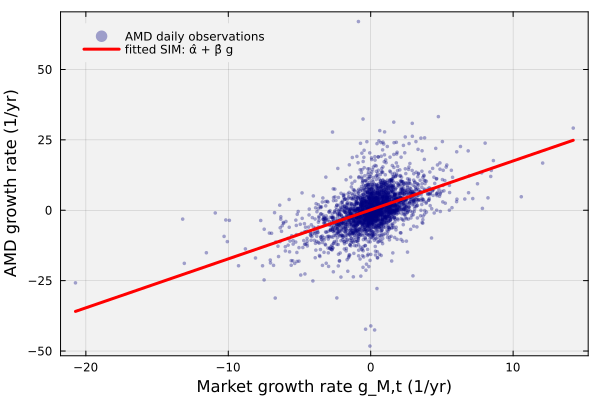

In [7]:
let
    scatter(g_market, y, ms = 2, msw = 0, alpha = 0.35, c = :navy, label = "$(my_test_ticker) daily observations")
    xs = range(minimum(g_market), maximum(g_market), length = 50);
    plot!(xs, θ̂[1] .+ θ̂[2] .* xs, c = :red, lw = 3, label = "fitted SIM: α̂ + β̂ g")
    plot!(xlabel = "Market growth rate g_M,t (1/yr)", ylabel = "$(my_test_ticker) growth rate (1/yr)", 
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

The cloud is wide: on any single day the market explains only part of the firm's move, and the rest is the residual. How much is "only part" is the subject of the next task.
___

## Task 2: Evaluate the Fit and Its Uncertainty
The residuals $\mathbf{r}=\mathbf{y}-\hat{\mathbf{X}}\hat{\boldsymbol{\theta}}$ are growth rates (units: inverse years), so their variance is a growth-rate variance and needs no time-step factor. The lecture's estimate of the residual growth-rate variance is:
$$
s^{2}_{g,\varepsilon} = \frac{\lVert\mathbf{r}\rVert_{2}^{2}}{N-2}
$$
where the two counts the estimated parameters, and the coefficient of determination is $R^{2}=1-\lVert\mathbf{r}\rVert_{2}^{2}/\sum_{t}(y_{t}-g^{\prime}_{i})^{2}$, where $g^{\prime}_{i}$ is the sample mean of the firm's growth rates. For a simple regression with an intercept, $R^{2}$ is also the squared sample correlation between the firm and the market, $R^{2}=\hat{\rho}_{iM}^{2}$, which we verify [using the `cor(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cor). We compute all of it, cross-checking $s^{2}_{g,\varepsilon}$ against [the built-in `var(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.var) applied to the residuals (they differ only in the degrees of freedom, $N-2$ versus $N-1$, since the residual mean is zero for a regression with an intercept). We store the results in the `s²_gε::Float64` and `R²::Float64` variables:

In [8]:
s²_gε, R² = let
    r = y .- X̂*θ̂; # residual growth rates (units: 1/years)
    s² = dot(r, r)/(N - 2); # residual growth-rate variance (units: 1/years²)
    @assert isapprox(s², var(r)*(N - 1)/(N - 2), rtol = 1e-10) # same up to the degrees of freedom
    R² = 1 - dot(r, r)/sum(abs2, y .- mean(y)); # fraction of the firm's growth-rate variation explained by the market
    @assert isapprox(R², cor(y, g_market)^2, rtol = 1e-10) # simple regression with an intercept: R² is the squared correlation
    (s², R²); # return
end;
println("$(my_test_ticker): residual growth-rate std s_gε = $(round(sqrt(s²_gε), digits=3)) 1/yr (diffusion volatility √Δt s_gε = $(round(sqrt(Δt*s²_gε), digits=4))), R² = $(round(R², digits=3))")

AMD: residual growth-rate std s_gε = 6.541 1/yr (diffusion volatility √Δt s_gε = 0.412), R² = 0.245


Under the lecture's classical assumptions (the design held fixed, errors with zero conditional mean, independent, homoskedastic, and Gaussian, $\boldsymbol{\varepsilon}\sim\mathcal{N}(\mathbf{0},\sigma^{2}_{g,\varepsilon}\mathbf{I})$), the covariance of the least-squares estimator is $\text{Cov}(\hat{\boldsymbol{\theta}})=\sigma^{2}_{g,\varepsilon}(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}$, estimated by replacing $\sigma^{2}_{g,\varepsilon}$ with $s^{2}_{g,\varepsilon}$; the standard errors are the square roots of its diagonal, and a 95% confidence interval is $\hat{\theta}_{j}\pm t_{0.975,N-2}\,\text{SE}(\hat{\theta}_{j})$ with the Student $t$ quantile from [the `TDist` distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.TDist) (with $N-2\approx2800$ degrees of freedom it is $1.96$ to three digits). Daily growth rates violate the independence and homoskedasticity parts of that list (L3a), so these are the classical intervals, and the uncertainty example asks how much that matters. We store the standard errors in the `SE::Array{Float64,1}` variable and tabulate the intervals [using the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/):

In [9]:
SE = sqrt.(s²_gε .* diag(inv(transpose(X̂)*X̂))); # classical standard errors of (α̂, β̂)
let
    t = quantile(TDist(N - 2), 0.975); # two-sided 95% critical value
    df = DataFrame(parameter = ["α (1/yr)", "β"], estimate = round.(θ̂, digits=4), SE = round.(SE, digits=4),
        CI_low = round.(θ̂ .- t*SE, digits=4), CI_high = round.(θ̂ .+ t*SE, digits=4), covers_zero = [(θ̂[j] - t*SE[j] ≤ 0 ≤ θ̂[j] + t*SE[j]) ? "yes" : "no" for j ∈ 1:2]);
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------- ---------- --------- --------- --------- -------------
  parameter   estimate        SE    CI_low   CI_high   covers_zero 
     String    Float64   Float64   Float64   Float64        String 
 ----------- ---------- --------- --------- --------- -------------
   α (1/yr)     0.1275    0.1245   -0.1167    0.3716           yes
          β     1.7392     0.058    1.6254    1.8529            no
 ----------- ---------- --------- --------- --------- -------------


Read the two rows differently. The beta is estimated precisely (a narrow interval well away from one), so the statement "this firm carries more systematic risk than the market" is well supported. The intercept's interval is wide relative to its value; whether it covers zero tells us whether the data can distinguish the firm's average growth from what its market exposure alone would deliver. And the $R^{2}$ says that the market explains only a fraction of the firm's daily variation; the rest is idiosyncratic. None of these three numbers is a forecast, and all of them depend on the market proxy, the sample window, and the constant-parameter assumption.

A single stock and an index fund tell different stories. Let's fit the contrast ticker (an ETF that tracks the Nasdaq-100) the same way and put the two side by side:

In [10]:
let
    function fit(ticker)
        yy = G[:, findfirst(==(ticker), list_of_tickers)]; θ = X̂ \ yy; r = yy .- X̂*θ; s2 = dot(r, r)/(N - 2);
        (θ = θ, SE = sqrt.(s2 .* diag(inv(transpose(X̂)*X̂))), s = sqrt(s2), R² = 1 - dot(r, r)/sum(abs2, yy .- mean(yy)))
    end
    rows = DataFrame(ticker = String[], α = Float64[], β = Float64[], SE_β = Float64[], s_gε = Float64[], R² = Float64[]);
    for ticker ∈ [my_test_ticker, contrast_ticker]
        f = fit(ticker); push!(rows, (ticker = ticker, α = round(f.θ[1], digits=4), β = round(f.θ[2], digits=4), SE_β = round(f.SE[2], digits=4), s_gε = round(f.s, digits=3), R² = round(f.R², digits=3)));
    end
    pretty_table(rows, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- --------- ---------
  ticker         α         β      SE_β      s_gε        R² 
  String   Float64   Float64   Float64   Float64   Float64 
 -------- --------- --------- --------- --------- ---------
     AMD    0.1275    1.7392     0.058     6.541     0.245
     QQQ    0.0413    1.1348    0.0094     1.057     0.841
 -------- --------- --------- --------- --------- ---------


The stock has the larger beta and the far smaller $R^{2}$: a high beta is a statement about systematic exposure, not about how much of the firm's variation the market explains, and a diversified index fund can have a modest beta and a very high $R^{2}$ because its idiosyncratic residual is small. Both numbers enter the SIM covariance of the next task, in different places.
___

## Task 3: Estimate a SIM for Every Security, Check the Residuals, and Save the Archive
L6b builds portfolios from the SIM parameters of many securities at once, so we now repeat the fit for every security in the cleaned dataset against the same market series. For each one we record the estimates, their standard errors and 95% intervals, the residual growth-rate variance $s^{2}_{g,\varepsilon}$ (growth-rate units), and $R^{2}$, as a [NamedTuple](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple), and collect them in the `sim_parameters::Dict{String,NamedTuple}` variable keyed by ticker; we also keep the residuals of every regression, one column per ticker, in the `E::Array{Float64,2}` variable for the diagnostic below. The market's own row is a mechanical sanity check: SPY regressed on itself must give $\alpha=0$, $\beta=1$, and $R^{2}=1$, and it is excluded from the summaries that follow:

In [11]:
sim_parameters, E = let
    XtX_inv = inv(transpose(X̂)*X̂); # shared by every regression (same market column)
    t = quantile(TDist(N - 2), 0.975);
    parameters = Dict{String, NamedTuple}();
    E = Array{Float64,2}(undef, N, number_of_securities); # residuals, one column per ticker
    for (i, ticker) ∈ enumerate(list_of_tickers)
        yᵢ = G[:, i];
        θᵢ = X̂ \ yᵢ; # least squares
        rᵢ = yᵢ .- X̂*θᵢ; E[:, i] = rᵢ;
        s²ᵢ = dot(rᵢ, rᵢ)/(N - 2); # residual growth-rate variance (units: 1/years²)
        SEᵢ = sqrt.(s²ᵢ .* diag(XtX_inv));
        R²ᵢ = 1 - dot(rᵢ, rᵢ)/sum(abs2, yᵢ .- mean(yᵢ));
        parameters[ticker] = (ticker = ticker, n_observations = N, n_parameters = 2, critical_value_95 = t,
            alpha = θᵢ[1], beta = θᵢ[2], alpha_SE = SEᵢ[1], beta_SE = SEᵢ[2],
            alpha_95_CI_lower = θᵢ[1] - t*SEᵢ[1], alpha_95_CI_upper = θᵢ[1] + t*SEᵢ[1],
            beta_95_CI_lower = θᵢ[2] - t*SEᵢ[2], beta_95_CI_upper = θᵢ[2] + t*SEᵢ[2],
            training_variance = s²ᵢ, r_squared = R²ᵢ); # training_variance = s²_gε (units: 1/years²)
    end
    spy = parameters[market_ticker];
    @assert isapprox(spy.alpha, 0.0, atol = 1e-10) && isapprox(spy.beta, 1.0, atol = 1e-10) && isapprox(spy.r_squared, 1.0, atol = 1e-10) # the market on itself
    (parameters, E); # return
end;
println("Estimated $(length(sim_parameters)) single index models")

Estimated 424 single index models


Let's look at the thirteen firms of the L5b examples: intercept, beta, the standard error of beta, the residual growth-rate standard deviation, and $R^{2}$:

In [12]:
let
    tickers_13 = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"];
    df = DataFrame(ticker = String[], α = Float64[], β = Float64[], SE_β = Float64[], s_gε = Float64[], R² = Float64[]);
    for ticker ∈ tickers_13
        d = sim_parameters[ticker];
        push!(df, (ticker = ticker, α = round(d.alpha, digits=3), β = round(d.beta, digits=3), SE_β = round(d.beta_SE, digits=3), s_gε = round(sqrt(d.training_variance), digits=3), R² = round(d.r_squared, digits=3)));
    end
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- --------- ---------
  ticker         α         β      SE_β      s_gε        R² 
  String   Float64   Float64   Float64   Float64   Float64 
 -------- --------- --------- --------- --------- ---------
    AAPL     0.106     1.195     0.024     2.701     0.474
    MSFT       0.1     1.152     0.021     2.366     0.522
    INTC    -0.148     1.184     0.035     3.921     0.296
      MU    -0.053     1.695     0.047     5.333     0.317
     AMD     0.127     1.739     0.058     6.541     0.245
    NVDA     0.347     1.749     0.043     4.898      0.37
      GS    -0.033      1.31     0.024     2.703      0.52
     BAC    -0.055     1.359     0.028     3.114     0.467
     WFC    -0.091     1.238     0.029     3.269     0.398
       C    -0.133     1.501     0.028     3.171     0.508
       F    -0.193     1.434     0.036     4.071     0.363
      GM    -0.129      1.47     0.036     4.012     0.382
     JNJ    -0.016      0.54     0.019     2.149    

The semiconductor names have betas well above one and large residual variances; the health-care name sits well below one, and the banks and automakers between about one and a quarter and one and a half. Across the whole universe (SPY excluded), how are the betas and the $R^{2}$ values distributed? Let's plot both [using the `histogram(...)` function](https://docs.juliaplots.org/stable/api/#Plots.histogram-Tuple):

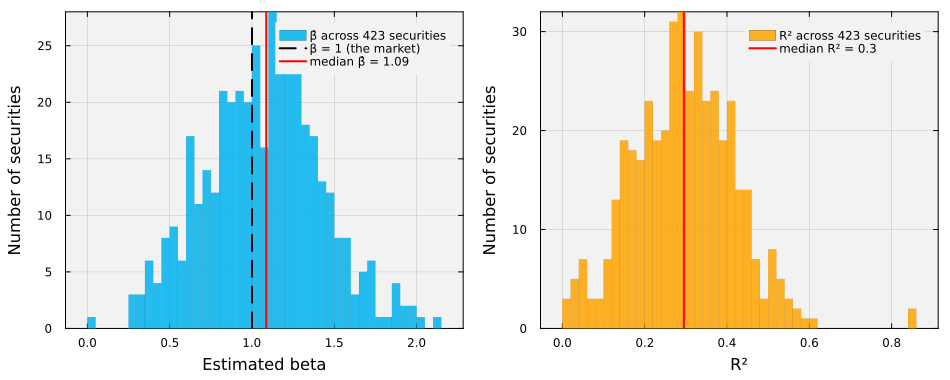

In [13]:
let
    others = filter(!=(market_ticker), list_of_tickers);
    βs = [sim_parameters[t].beta for t ∈ others]; R²s = [sim_parameters[t].r_squared for t ∈ others];
    p1 = histogram(βs, bins = 40, c = :deepskyblue2, lw = 0, alpha = 0.85, label = "β̂ across $(length(βs)) securities", xlabel = "Estimated beta", ylabel = "Number of securities")
    vline!(p1, [1.0], c = :black, lw = 2, ls = :dash, label = "β = 1 (the market)")
    vline!(p1, [median(βs)], c = :red, lw = 2, label = "median β̂ = $(round(median(βs), digits=2))")
    p2 = histogram(R²s, bins = 40, c = :orange, lw = 0, alpha = 0.85, label = "R² across $(length(R²s)) securities", xlabel = "R²", ylabel = "Number of securities")
    vline!(p2, [median(R²s)], c = :red, lw = 2, label = "median R² = $(round(median(R²s), digits=2))")
    plot(p1, p2, layout = (1, 2), size = (950, 380), bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
end

Before we hand these fits to L6b, one check the lecture insists on. The SIM covariance $\mathbf{\Sigma}_{g}=\sigma^{2}_{g,M}\boldsymbol{\beta}\boldsymbol{\beta}^{\top}+\mathbf{D}_{g}$ assumes the residuals of different securities are __uncorrelated__ with each other. Fitting each regression separately guarantees nothing of the kind: each residual vector is orthogonal to the market column, not to the other residuals. Let's compute the sample correlation matrix of the residuals of all securities (SPY excluded, since its residual is zero), summarize the off-diagonal entries, name the most correlated pair, and show the residual correlations of the thirteen L5b firms as a heatmap [using the `heatmap(...)` function](https://docs.juliaplots.org/stable/api/#Plots.heatmap-Tuple):

Off-diagonal residual correlations: median |ρ| = 0.071, 95th percentile of |ρ| = 0.27, max |ρ| = 0.981 for FOXA and FOX


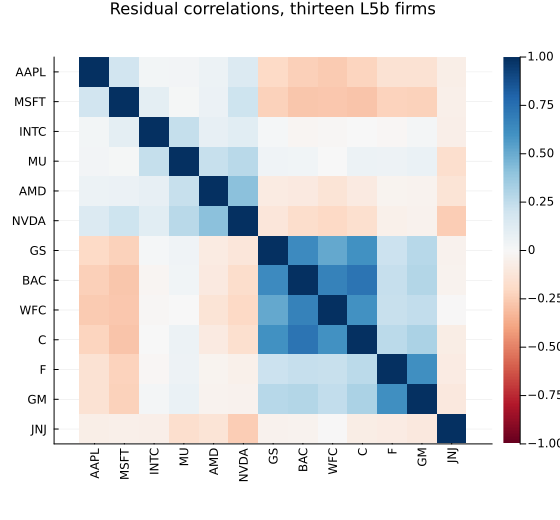

In [14]:
let
    others = findall(!=(market_ticker), list_of_tickers);
    ρ_E = cor(E[:, others]); # residual correlation matrix (SPY excluded)
    pairs = [(i, j) for i ∈ 1:length(others) for j ∈ 1:(i-1)];
    offdiag = [ρ_E[i, j] for (i, j) ∈ pairs];
    k = argmax(abs.(offdiag)); (i_max, j_max) = pairs[k];
    println("Off-diagonal residual correlations: median |ρ| = $(round(median(abs.(offdiag)), digits=3)), 95th percentile of |ρ| = $(round(quantile(abs.(offdiag), 0.95), digits=3)), max |ρ| = $(round(abs(offdiag[k]), digits=3)) for $(list_of_tickers[others[i_max]]) and $(list_of_tickers[others[j_max]])")
    tickers_13 = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"];
    idx = [findfirst(==(t), list_of_tickers) for t ∈ tickers_13];
    heatmap(cor(E[:, idx]), xticks = (1:13, tickers_13), yticks = (1:13, tickers_13), xrotation = 90, color = :RdBu, clims = (-1, 1), colorbar_ticks = (-1:0.5:1),
        aspect_ratio = :equal, yflip = true, title = "Residual correlations, thirteen L5b firms", titlefontsize = 11, size = (560, 520))
end

Most pairs are close to uncorrelated, which is what makes the SIM covariance usable, but the tails are not: pairs in the same industry (banks with banks, semiconductors with semiconductors) keep a residual correlation of a few tenths, and near-duplicate securities are almost perfectly correlated. Those are the covariances the SIM sets to zero; L6b's covariance model inherits that approximation, and this is the number to quote when asked how good it is.

Finally, we save the archive to `data/SIMs-SP500-01-03-14-to-12-31-24.jld2` [using the `save(...)` function](https://juliaio.github.io/JLD2.jl/stable/#save-and-load) from JLD2, with the metadata a downstream user needs: the market ticker, the training mean and variance of the market growth rate (L6b must use these, not moments recomputed on later data), the time step, the growth-rate definition, the date range, and the ticker list. The `variance_convention` entry records that `training_variance` is the residual growth-rate variance $s^{2}_{g,\varepsilon}$ (units: inverse years squared), the convention the L6b examples expect:

In [15]:
let
    path_to_save_file = joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2");
    save(path_to_save_file, Dict(
        "data" => sim_parameters,
        "market_ticker" => market_ticker,
        "market_mean" => mean(g_market), # training-period mean market growth rate (units: 1/years)
        "market_variance" => var(g_market), # training-period market growth-rate variance (units: 1/years²)
        "delta_t" => Δt,
        "growth_definition" => "g_t = log(S_t/S_{t-1})/Δt with S the volume-weighted average price; units 1/years; no risk-free rate subtracted",
        "date_range" => (string(dataset[market_ticker].timestamp[1]), string(dataset[market_ticker].timestamp[end])),
        "list_of_tickers" => list_of_tickers,
        "variance_convention" => "growth_rate", # training_variance = s²_gε in (1/years)², no Δt factor
        "schema_version" => 2
    ));
    println("Saved $(length(sim_parameters)) SIM parameter sets to $(path_to_save_file)")
end

Saved 424 SIM parameter sets to /Users/jeffreyvarner/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026/lectures/week-6/L6a/data/SIMs-SP500-01-03-14-to-12-31-24.jld2


L6b's examples read this archive from their own `data/` folder, so the last step publishes a byte-identical copy there. This cell is the only place in the notebook that writes outside L6a; it checks that the copy matches the original byte for byte [using the `read(...)` function](https://docs.julialang.org/en/v1/base/io-network/#Base.read):

In [16]:
let
    source = joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2");
    destination = normpath(joinpath(_ROOT, "..", "L6b", "data", "SIMs-SP500-01-03-14-to-12-31-24.jld2"));
    cp(source, destination, force = true);
    @assert read(source) == read(destination) # the published copy is byte-identical
    println("Published to $(destination)")
end

Published to /Users/jeffreyvarner/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026/lectures/week-6/L6b/data/SIMs-SP500-01-03-14-to-12-31-24.jld2


___

## Summary
In this example, we estimated single index models from the training data: one firm by hand with three equivalent least-squares solvers, its classical uncertainty and fit statistics in growth-rate units next to those of an index fund, and then every security in the dataset, with the residual-correlation check that the SIM covariance assumes away, saved as the parameter archive that L6b builds portfolios from.

> __Key Takeaways:__
>
> * **One estimator, several algorithms:** The normal equations, a QR-based backslash solve, and the singular value decomposition return the same least-squares estimates whenever the design has full column rank; they differ in numerical stability, which does not show on a two-column design but is the reason to avoid forming an explicit inverse in general.
> * **Units come from the observations, and beta is not fit:** Because the regression is fit to growth rates, the residual variance, the standard errors, and the parameter archive are all in growth-rate units with no time-step factor; and a high beta with a low coefficient of determination (the stock) versus a modest beta with a high one (the index fund) shows that systematic exposure and explained variation are different things.
> * **The SIM covariance rests on an assumption the fits do not enforce:** Fitting every security against the market gives betas from near zero to above two around a median close to one, but the residuals of related securities remain correlated by a few tenths and near-duplicates almost perfectly, which is exactly what the diagonal residual covariance of L6b sets to zero.

L6b turns these per-firm parameters into a covariance matrix and a portfolio; the companion uncertainty example asks how much the parameters themselves move under resampling.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___